In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
# Load your cleaned data
df = pd.read_csv('AAPL_final.csv')

# First, inspect the data and dtypes
print("Data shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(2))

# Select only numeric columns that make sense for prediction
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# Use numeric columns, excluding index columns
features_to_use = [col for col in numeric_cols if col not in ['Unnamed: 0', 'id']]
print(f"\nUsing features: {features_to_use}")

# Extract data and remove rows with NaN/infinity
data = df[features_to_use].dropna().values
data = data[~np.isinf(data).any(axis=1)]  # Remove rows with infinity values

print(f"Data shape after cleaning: {data.shape}")
print(f"Data type: {data.dtype}")

if data.shape[0] < 35:
    print("WARNING: Not enough data points for sequence length of 30")
    print("Using sequence length of", max(1, data.shape[0] - 5))
    sequence_length = max(1, data.shape[0] - 5)
else:
    sequence_length = 30

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length].flatten())
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

print(f"\nSequences created - X shape: {X.shape}, y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Test set: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build neural network model (more stable than LSTM without TensorFlow)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=15,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=1
)

# Train the model
print("\nTraining model...")
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'\nTrain R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate additional metrics
mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100, 0], label='Actual', marker='o', alpha=0.7)
plt.plot(predictions[:100, 0], label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title('Neural Network Predictions vs Actual')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()

print("\nModel training complete!")

Data shape: (914962, 30)

Column dtypes:
Unnamed: 0            int64
id                    int64
body                 object
created_at           object
user                 object
source               object
symbols              object
owned_symbols        object
mentioned_users      object
entities              int64
conversation         object
likes                object
links                object
reshares             object
reshare_message      object
structurable         object
body_clean           object
body_no_stopwords    object
hour                  int64
minute                int64
time_period          object
day_of_week           int64
day_name             object
is_weekend            int64
day_of_month          int64
month                 int64
quarter               int64
week_of_year          int64
year                  int64
posts_per_hour        int64
dtype: object

First few rows:
   Unnamed: 0         id                                               body  \
0        

Data shape: (539803, 29)

Column dtypes:
Unnamed: 0            int64
id                    int64
body                 object
created_at           object
user                 object
source               object
symbols              object
mentioned_users      object
entities              int64
links                object
likes                object
conversation         object
reshares             object
reshare_message      object
owned_symbols        object
body_clean           object
body_no_stopwords    object
hour                  int64
minute                int64
time_period          object
day_of_week           int64
day_name             object
is_weekend            int64
day_of_month          int64
month                 int64
quarter               int64
week_of_year          int64
year                  int64
posts_per_hour        int64
dtype: object

First few rows:
   Unnamed: 0         id                                               body  \
0        5986  171509246  $AMZN $FB $

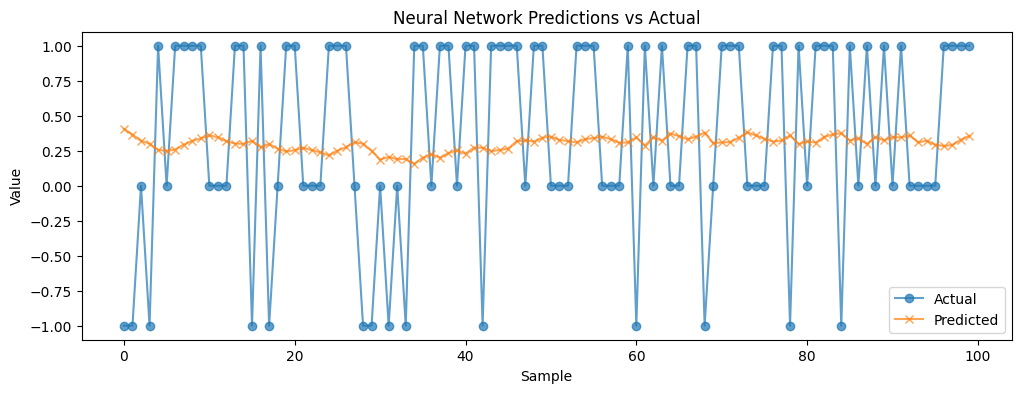


Model training complete!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')
# Load your cleaned data
df = pd.read_csv('AMZN_final.csv')

# First, inspect the data and dtypes
print("Data shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(2))

# Select only numeric columns that make sense for prediction
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# Use numeric columns, excluding index columns
features_to_use = [col for col in numeric_cols if col not in ['Unnamed: 0', 'id']]
print(f"\nUsing features: {features_to_use}")

# Extract data and remove rows with NaN/infinity
data = df[features_to_use].dropna().values
data = data[~np.isinf(data).any(axis=1)]  # Remove rows with infinity values

print(f"Data shape after cleaning: {data.shape}")
print(f"Data type: {data.dtype}")

if data.shape[0] < 35:
    print("WARNING: Not enough data points for sequence length of 30")
    print("Using sequence length of", max(1, data.shape[0] - 5))
    sequence_length = max(1, data.shape[0] - 5)
else:
    sequence_length = 30

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length].flatten())
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

print(f"\nSequences created - X shape: {X.shape}, y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Test set: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build neural network model (more stable than LSTM without TensorFlow)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=15,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=1
)

# Train the model
print("\nTraining model...")
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'\nTrain R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate additional metrics
mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100, 0], label='Actual', marker='o', alpha=0.7)
plt.plot(predictions[:100, 0], label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title('Neural Network Predictions vs Actual')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()

print("\nModel training complete!")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

NameError: name 'y_test_actual' is not defined

Data shape: (359908, 29)

Column dtypes:
Unnamed: 0            int64
id                    int64
body                 object
created_at           object
user                 object
source               object
symbols              object
mentioned_users      object
entities              int64
conversation         object
likes                object
links                object
reshare_message      object
reshares             object
owned_symbols        object
body_clean           object
body_no_stopwords    object
hour                  int64
minute                int64
time_period          object
day_of_week           int64
day_name             object
is_weekend            int64
day_of_month          int64
month                 int64
quarter               int64
week_of_year          int64
year                  int64
posts_per_hour        int64
dtype: object

First few rows:
   Unnamed: 0         id                                               body  \
0       14983  171486171             

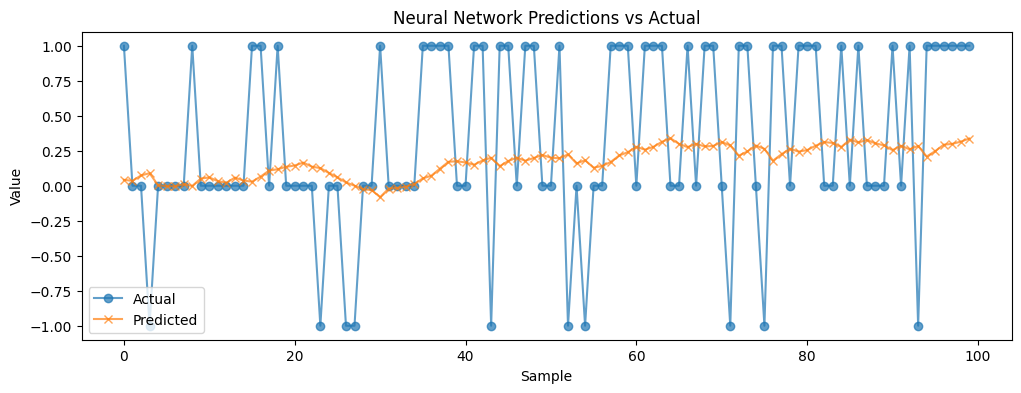


Model training complete!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')
# Load your cleaned data
df = pd.read_csv('FB_final.csv')

# First, inspect the data and dtypes
print("Data shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(2))

# Select only numeric columns that make sense for prediction
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# Use numeric columns, excluding index columns
features_to_use = [col for col in numeric_cols if col not in ['Unnamed: 0', 'id']]
print(f"\nUsing features: {features_to_use}")

# Extract data and remove rows with NaN/infinity
data = df[features_to_use].dropna().values
data = data[~np.isinf(data).any(axis=1)]  # Remove rows with infinity values

print(f"Data shape after cleaning: {data.shape}")
print(f"Data type: {data.dtype}")

if data.shape[0] < 35:
    print("WARNING: Not enough data points for sequence length of 30")
    print("Using sequence length of", max(1, data.shape[0] - 5))
    sequence_length = max(1, data.shape[0] - 5)
else:
    sequence_length = 30

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length].flatten())
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

print(f"\nSequences created - X shape: {X.shape}, y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Test set: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build neural network model (more stable than LSTM without TensorFlow)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=15,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=1
)

# Train the model
print("\nTraining model...")
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'\nTrain R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate additional metrics
mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100, 0], label='Actual', marker='o', alpha=0.7)
plt.plot(predictions[:100, 0], label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title('Neural Network Predictions vs Actual')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()

print("\nModel training complete!")

Data shape: (584181, 30)

Column dtypes:
Unnamed: 0            int64
id                    int64
body                 object
created_at           object
user                 object
source               object
symbols              object
mentioned_users      object
entities              int64
likes                object
conversation         object
links                object
reshare_message      object
reshares             object
owned_symbols        object
structurable         object
body_clean           object
body_no_stopwords    object
hour                  int64
minute                int64
time_period          object
day_of_week           int64
day_name             object
is_weekend            int64
day_of_month          int64
month                 int64
quarter               int64
week_of_year          int64
year                  int64
posts_per_hour        int64
dtype: object

First few rows:
   Unnamed: 0        id                                               body  \
0       14

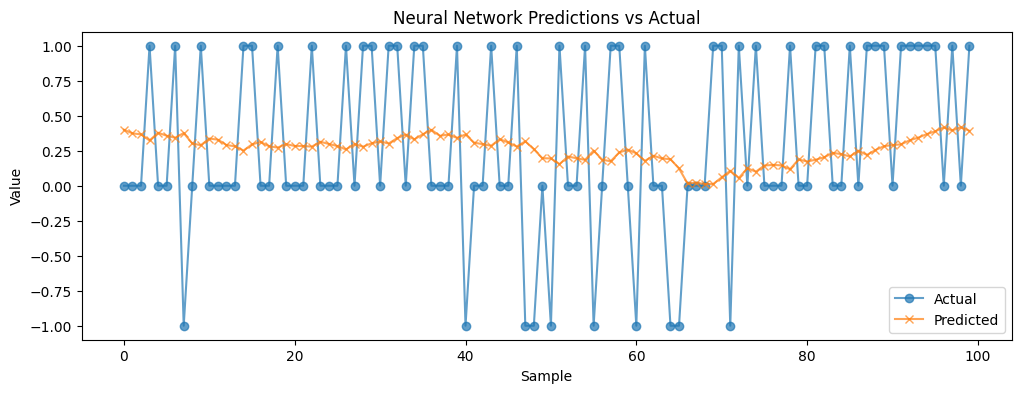


Model training complete!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')
# Load your cleaned data
df = pd.read_csv('NVDA_final.csv')

# First, inspect the data and dtypes
print("Data shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(2))

# Select only numeric columns that make sense for prediction
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# Use numeric columns, excluding index columns
features_to_use = [col for col in numeric_cols if col not in ['Unnamed: 0', 'id']]
print(f"\nUsing features: {features_to_use}")

# Extract data and remove rows with NaN/infinity
data = df[features_to_use].dropna().values
data = data[~np.isinf(data).any(axis=1)]  # Remove rows with infinity values

print(f"Data shape after cleaning: {data.shape}")
print(f"Data type: {data.dtype}")

if data.shape[0] < 35:
    print("WARNING: Not enough data points for sequence length of 30")
    print("Using sequence length of", max(1, data.shape[0] - 5))
    sequence_length = max(1, data.shape[0] - 5)
else:
    sequence_length = 30

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length].flatten())
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

print(f"\nSequences created - X shape: {X.shape}, y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Test set: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build neural network model (more stable than LSTM without TensorFlow)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=15,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=1
)

# Train the model
print("\nTraining model...")
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'\nTrain R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate additional metrics
mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100, 0], label='Actual', marker='o', alpha=0.7)
plt.plot(predictions[:100, 0], label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title('Neural Network Predictions vs Actual')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()

print("\nModel training complete!")

Data shape: (2204889, 30)

Column dtypes:
Unnamed: 0            int64
id                    int64
body                 object
created_at           object
user                 object
source               object
symbols              object
mentioned_users      object
entities              int64
links                object
likes                object
conversation         object
reshare_message      object
owned_symbols        object
reshares             object
structurable         object
body_clean           object
body_no_stopwords    object
hour                  int64
minute                int64
time_period          object
day_of_week           int64
day_name             object
is_weekend            int64
day_of_month          int64
month                 int64
quarter               int64
week_of_year          int64
year                  int64
posts_per_hour        int64
dtype: object

First few rows:
   Unnamed: 0         id                                               body  \
0       

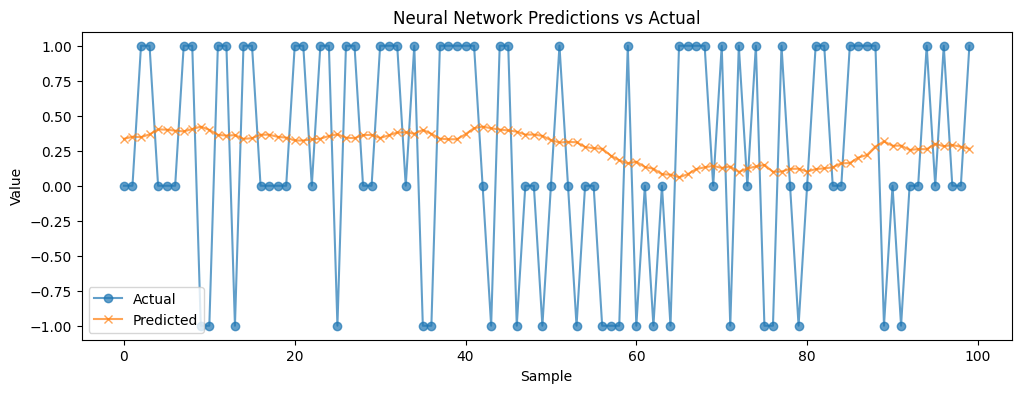


Model training complete!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')
# Load your cleaned data
df = pd.read_csv('TSLA_final.csv')

# First, inspect the data and dtypes
print("Data shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head(2))

# Select only numeric columns that make sense for prediction
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# Use numeric columns, excluding index columns
features_to_use = [col for col in numeric_cols if col not in ['Unnamed: 0', 'id']]
print(f"\nUsing features: {features_to_use}")

# Extract data and remove rows with NaN/infinity
data = df[features_to_use].dropna().values
data = data[~np.isinf(data).any(axis=1)]  # Remove rows with infinity values

print(f"Data shape after cleaning: {data.shape}")
print(f"Data type: {data.dtype}")

if data.shape[0] < 35:
    print("WARNING: Not enough data points for sequence length of 30")
    print("Using sequence length of", max(1, data.shape[0] - 5))
    sequence_length = max(1, data.shape[0] - 5)
else:
    sequence_length = 30

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length].flatten())
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

print(f"\nSequences created - X shape: {X.shape}, y shape: {y.shape}")

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train set: X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Test set: X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build neural network model (more stable than LSTM without TensorFlow)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=15,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=1
)

# Train the model
print("\nTraining model...")
model.fit(X_train, y_train)

# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'\nTrain R² Score: {train_score:.4f}')
print(f'Test R² Score: {test_score:.4f}')

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate additional metrics
mae = mean_absolute_error(y_test_actual, predictions)
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
print(f'\nMean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100, 0], label='Actual', marker='o', alpha=0.7)
plt.plot(predictions[:100, 0], label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title('Neural Network Predictions vs Actual')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.show()

print("\nModel training complete!")